In [1]:
import math
import dataclasses
import os
from time import time

import jax
import jax.numpy as jnp
from jax import Array, lax
from jax.scipy.ndimage import map_coordinates
from flax import linen as nn

import optax
from functools import partial
import numpy as np

import matdecomp_schaff

# Helpers

In [136]:
# Wavelength conversion

h  = 6.62607015e-34           # Planck constant, J/Hz
c = 299792458.0               # speed of light, m/s
J_eV = 1.602176565e-19        # J per eV conversion
PI = 3.14159

def get_wavelen(energy):
    return 1e-3*h*c / (energy*J_eV)

def get_wavenum(energy):
    return 2*PI / get_wavelen(energy)

In [3]:
# Figures

import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import matplotlib.colors as colors
from cycler import cycler
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

def add_scalebar(ax, sz, Nx, real_dx, real_units, color='k', sv=1):
    width_px = sz * Nx 
    label = f'{real_dx * width_px:.0f} {real_units}'
    scalebar = AnchoredSizeBar(ax.transData, width_px, label, 'lower left', size_vertical=sv, frameon=False, color=color)
    ax.add_artist(scalebar)

def add_scalebar2(ax, width_px, dx_per_px, real_units, color='k', sv=1):
    label = f'{dx_per_px * width_px:.0f} {real_units}'
    scalebar = AnchoredSizeBar(ax.transData, width_px, label, 'lower left', size_vertical=sv, frameon=False, color=color)
    ax.add_artist(scalebar)
    
custom_colors = ['#0072B2', '#009E73', '#F0E442', '#D55E00', '#CC79A7']
ccs = custom_colors
custom_cycler = cycler('color', custom_colors)  # color-blind friendly

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size':10,
    'axes.titlesize':10,
    'axes.labelsize':8,
    'axes.linewidth': .5,
    'axes.prop_cycle': custom_cycler,
    'xtick.top': True, 
    'ytick.right': True, 
    'xtick.direction': 'in', 
    'ytick.direction': 'in',
    'xtick.labelsize':8,
    'ytick.labelsize':8,
    'legend.fontsize': 8,
    'lines.linewidth':1,
    'image.cmap':'gray',
    'text.usetex': True,
    'font.family': 'serif'
})

In [4]:
# Materials

os.chdir('..')
from src.xpc.xscatter import Material, nist_mc, victre_matdict
os.chdir('multislice')

Water = Material(
    'water',
     density = 1.0,
     matcomp = nist_mc['Water, Liquid']
)

PMMA = Material(
    'PMMA',
    density = 1.190,
    matcomp = nist_mc['Polymethyl Methacrylate']
)

Aluminum = Material(
    'aluminum',
    density = 2.699,
    matcomp = 'Al(100)'
)

In [5]:
# PSF helpers

def lorentzian1D(x, fwhm, normalize=True):
    gamma = fwhm / 2
    kernel = gamma / (jnp.pi * (x**2 + gamma**2))

    if normalize:
        kernel = kernel / jnp.sum(kernel)

    return kernel


def gaussian1D(x, fwhm, normalize=True):
    sigma = fwhm / (2 * jnp.sqrt(2 * jnp.log(2)))
    kernel = jnp.exp(-0.5 * (x / sigma)**2)

    if normalize:
        kernel = kernel / jnp.sum(kernel)

    return kernel


def get_psf_kernel_size(dx, fwhm, psf='lorentzian', rel_thresh=1e-3, max_kernel_width=8.0):
    psf = psf.lower()

    if psf == 'lorentzian':
        gamma = fwhm / 2
        half_width = gamma * math.sqrt(1 / rel_thresh - 1)

    elif psf == 'gaussian':
        sigma = fwhm / (2 * math.sqrt(2 * math.log(2)))
        half_width = sigma * math.sqrt(2 * math.log(1 / rel_thresh))

    else:
        raise ValueError(f'Unknown PSF: {psf}')

    if max_kernel_width is not None:
        half_width = min(half_width, max_kernel_width * fwhm)

    n_half = max(1, math.ceil(half_width / dx))

    return n_half


def get_psf_kernel1D(dx, fwhm, psf='lorentzian', rel_thresh=1e-3, max_kernel_width=8.0):
    psf = psf.lower()

    n_half = get_psf_kernel_size(
        dx = dx,
        fwhm = fwhm,
        psf = psf,
        rel_thresh = rel_thresh,
        max_kernel_width = max_kernel_width,
    )

    x = jnp.arange(-n_half, n_half + 1) * dx

    if psf == 'lorentzian':
        return lorentzian1D(x, fwhm)

    elif psf == 'gaussian':
        return gaussian1D(x, fwhm)

    else:
        raise ValueError(f'Unknown PSF: {psf}')


def prepare_psf1D(N, dx, fwhm=None, psf='lorentzian', rel_thresh=1e-3, max_kernel_width=8.0):
    if fwhm is None:
        return None

    kernel = get_psf_kernel1D(
        dx = dx,
        fwhm = fwhm,
        psf = psf,
        rel_thresh = rel_thresh,
        max_kernel_width = max_kernel_width,
    )

    K = kernel.shape[0]
    pad = (K - 1) // 2
    N_pad = N + 2 * pad
    fft_N = N_pad + K - 1
    G = jnp.fft.rfft(kernel, n=fft_N)
    o = (K - 1) // 2

    return dict(
        kernel = kernel,
        G = G,
        K = K,
        pad = pad,
        N_pad = N_pad,
        fft_N = fft_N,
        o = o,
    )


def convolve1d_diy_precomp(img, psf_pars):
    G = psf_pars['G']
    fft_N = psf_pars['fft_N']
    o = psf_pars['o']
    N = img.shape[-1]

    F = jnp.fft.rfft(img, n=fft_N, axis=-1)
    out = jnp.fft.irfft(F * G, n=fft_N, axis=-1)

    return out[..., o:o+N]


def apply_psf1D_precomp(img, psf_pars):
    if psf_pars is None:
        return img

    pad = psf_pars['pad']

    pad_width = [(0, 0)] * img.ndim
    pad_width[-1] = (pad, pad)

    img_pad = jnp.pad(img, pad_width, mode='edge')
    img_nonideal_pad = convolve1d_diy_precomp(img_pad, psf_pars)
    img_nonideal = img_nonideal_pad[..., pad:-pad]

    return img_nonideal

In [6]:
# Detector helpers


def prepare_detector1D(Nx, dx, det_Nx, upx):
    assert Nx >= det_Nx * upx

    N_crop = det_Nx * upx
    i0 = (Nx - N_crop) // 2
    i1 = i0 + N_crop

    return dict(
        Nx = int(Nx),
        dx = dx,
        det_Nx = int(det_Nx),
        upx = int(upx),
        det_dx = upx * dx,
        N_crop = int(N_crop),
        i0 = int(i0),
        i1 = int(i1),
    )


def block_average_detector1D(img, det_pars):
    upx = det_pars['upx']
    det_Nx = det_pars['det_Nx']
    i0 = det_pars['i0']
    i1 = det_pars['i1']

    img = img[..., i0:i1]

    if upx == 1:
        return img

    img = img.reshape(*img.shape[:-1], det_Nx, upx)

    return jnp.mean(img, axis=-1)


In [7]:
# XPCI helpers

def prepare_fresnel_transfer1D(N, dx, wavelens, propdist):
    freqs = jnp.fft.fftfreq(N, d=dx)
    Hs = jnp.exp(-1j * jnp.pi * wavelens[:, None] * propdist * freqs[None, :]**2)

    return Hs


In [8]:
# CT helpers

def make_rotation_locations_2d(shape, angle, dtype=jnp.float32):
    Ny, Nx = shape

    cy = (Ny - 1) / 2
    cx = (Nx - 1) / 2

    y = jnp.arange(Ny, dtype=dtype) - cy
    x = jnp.arange(Nx, dtype=dtype) - cx

    yy, xx = jnp.meshgrid(y, x, indexing='ij')

    cos_t = jnp.cos(angle).astype(dtype)
    sin_t = jnp.sin(angle).astype(dtype)

    y_in = cos_t * yy - sin_t * xx
    x_in = sin_t * yy + cos_t * xx

    y_in = y_in + cy
    x_in = x_in + cx

    return jnp.stack([y_in, x_in], axis=0)


def rotate_image(image, angle, cval=0.0):
    locs = make_rotation_locations_2d(
        shape = image.shape,
        angle = angle,
        dtype = image.real.dtype,
    )

    return map_coordinates(
        image,
        locs,
        order = 1,
        mode = 'constant',
        cval = cval,
    )

def select_energy_array(arr, i, nE):
    if arr.ndim == 2:
        return arr

    elif arr.ndim == 3:
        assert arr.shape[0] == nE
        return arr[i]

    else:
        raise ValueError('Expected arr to have shape (Nx, Nx) or (nE, Nx, Nx).')

In [9]:
# FBP
DTYPE = jnp.float32
PI = jnp.pi

def get_recon_coords(N_matrix, FOV):
    x = (FOV / N_matrix) * jnp.arange((1 - N_matrix) / 2, N_matrix / 2, 1, dtype=DTYPE)
    X, Y = jnp.meshgrid(x, -x, indexing='xy')
    r_matrix = jnp.sqrt(X**2 + Y**2)
    theta_matrix = jnp.arctan2(X, Y) + PI
    return r_matrix, theta_matrix


def make_ramp_filter_fourier(
    N_channels,
    s,
    cutoff_frac=0.5,
    window='hann',
):
    """
    Windowed Fourier-domain ramp filter for parallel-beam FBP.

    cutoff_frac:
        Fraction of Nyquist frequency to keep.
        1.0 = full ramp
        0.5 = smoother / more low-pass
        0.25 = very smooth
    """
    freq = jnp.fft.rfftfreq(N_channels, d=s)
    f_nyq = 1 / (2 * s)
    f_cut = cutoff_frac * f_nyq

    ramp = 2.0 * jnp.abs(freq)

    x = jnp.clip(freq / f_cut, 0.0, 1.0)

    if window == 'hann':
        win = 0.5 * (1.0 + jnp.cos(jnp.pi * x))
        win = jnp.where(freq <= f_cut, win, 0.0)

    elif window == 'hamming':
        win = 0.54 + 0.46 * jnp.cos(jnp.pi * x)
        win = jnp.where(freq <= f_cut, win, 0.0)

    elif window == 'cosine':
        win = jnp.cos(0.5 * jnp.pi * x)
        win = jnp.where(freq <= f_cut, win, 0.0)

    elif window == 'hard':
        win = jnp.where(freq <= f_cut, 1.0, 0.0)

    elif window is None:
        win = jnp.ones_like(freq)

    else:
        raise ValueError(f'Unknown window: {window}')

    H = ramp * win

    return H.astype(DTYPE)
    


@partial(jax.jit, static_argnames=())
def pre_process_fft(sino_log, s, H):
    """
    FFT-based filtering along detector-channel axis.
    """
    sino_f = jnp.fft.rfft(sino_log, axis=1)
    sino_filtered = jnp.fft.irfft(sino_f * H[None, :], n=sino_log.shape[1], axis=1)
    return sino_filtered.astype(DTYPE)


@partial(jax.jit, static_argnames=())
def do_fbp_vmap(sino, r_matrix, theta_matrix, dchannel, dtheta):
    """
    Vectorized parallel-beam filtered backprojection.
    """
    N_proj, N_channels = sino.shape
    beam_width = dchannel * N_channels

    beta = jnp.arange(N_proj, dtype=DTYPE) * dtheta + PI

    def backproject_one_proj(proj_row, beta_i):
        channel_targets = r_matrix * jnp.cos(theta_matrix - beta_i)
        i_channel_matrix = ((channel_targets + beam_width / 2) / dchannel).astype(jnp.int32)

        fbp_i = jnp.take(proj_row, i_channel_matrix, mode='clip')
        fbp_i = jnp.nan_to_num(fbp_i)
        return fbp_i

    all_proj = jax.vmap(backproject_one_proj, in_axes=(0, 0), out_axes=0)(sino, beta)
    matrix = jnp.sum(all_proj, axis=0) * dtheta

    return matrix.astype(DTYPE)


def get_recon(sino_log, N_matrix, FOV, s, dbeta):
    r_matrix, theta_matrix = get_recon_coords(N_matrix, FOV)
    H = make_ramp_filter_fourier(sino_log.shape[1], s)

    sino_filtered = pre_process_fft(sino_log, s, H)
    recon = do_fbp_vmap(sino_filtered, r_matrix, theta_matrix, s, dbeta)

    return recon


In [140]:
# Paganin phase retrieval

def paganin_1row(
    row, dx, R, energy, material=Water, I0=1.0, return_log=True
):
    wavelen = get_wavelen(energy)
    delta, beta = material.delta_beta(energy)
    mu = 4 * np.pi * beta / wavelen

    n = row.size
    f = np.fft.fftfreq(n, d=dx)
    k2 = (2 * np.pi * f)**2
    
    # arg = mu * np.fft.fft(row) / (R * delta * f**2 + mu)
    arg = mu * np.fft.fft(row) / (R * delta * k2 + mu)

    # T = - (1/mu) * np.log(np.fft.ifft(arg))
    
    sino_log = - np.real(np.log(np.fft.ifft(arg)))
    T = sino_log / mu     
    
    if return_log:
        return sino_log
        
    return T
    

def paganin_retrieve_sino(
    sino, dx, energy, propdist, material=Water, I0=1.0, return_log=True
):
    paganin_sino = np.zeros(sino.shape, dtype=np.float32)
    for i in range(sino.shape[0]):
        paganin_sino[i] = paganin_1row(sino[i], dx, propdist, energy, material, I0, return_log)
        
    return paganin_sino

In [11]:
# Phantom

def make_circle_cluster_phantom(
    Nx: int = 64,
    Ny: int | None = None,
    dx: float = 1.0,
    r_main: float = 10.0,
    r_ring: float = 18.0,
    r_smalls = (2.0, 2.0, 2.0, 2.0, 2.0, 2.0),
    dtype=jnp.float32,
):
    if Ny is None:
        Ny = Nx

    r_smalls = jnp.asarray(r_smalls, dtype=dtype)
    n_small = len(r_smalls)

    y = (jnp.arange(Ny, dtype=dtype) - (Ny - 1) / 2) * dx
    x = (jnp.arange(Nx, dtype=dtype) - (Nx - 1) / 2) * dx
    yy, xx = jnp.meshgrid(y, x, indexing='ij')

    phantom = jnp.zeros((Ny, Nx), dtype=dtype)

    main_mask = xx**2 + yy**2 <= r_main**2
    phantom = jnp.where(main_mask, 1.0, phantom)

    angles = jnp.linspace(0.0, 2 * jnp.pi, n_small, endpoint=False)

    for theta, r_small in zip(angles, r_smalls):
        xc = r_ring * jnp.cos(theta)
        yc = r_ring * jnp.sin(theta)
        small_mask = (xx - xc)**2 + (yy - yc)**2 <= r_small**2
        phantom = jnp.where(small_mask, 2.0, phantom)

    return phantom

In [12]:
# Multislice

def prepare_multislice_pars(Nx, dx, dz=None):
    if dz is None:
        dz = dx

    ratio = dz / dx
    slice_step = int(round(ratio))

    if not math.isclose(ratio, slice_step, rel_tol=0.0, abs_tol=1e-12):
        raise ValueError('Require dz to be an integer multiple of dx.')

    if Nx % slice_step != 0:
        raise ValueError('Require Nx % slice_step == 0.')

    Nz = Nx // slice_step

    return dict(
        slice_step = int(slice_step),
        Nz = int(Nz),
        dz = slice_step * dx,
    )


def coarsen_object_slices(arr, ms_pars):
    slice_step = ms_pars['slice_step']
    Nz = ms_pars['Nz']

    if slice_step == 1:
        return arr

    arr = arr.reshape(Nz, slice_step, arr.shape[-1])

    return jnp.mean(arr, axis=1)

# PBI simulations

In [13]:
class PBI_1D_Base(nn.Module):
    
    # Simulation settings
    propdist: float = 10e-3
    I0_per_um2: float = 1e3
    energies: jnp.ndarray = dataclasses.field(
        default_factory=lambda: jnp.array([14.0])
    )
    thetas: jnp.ndarray = dataclasses.field(
        default_factory=lambda: jnp.array([0.0])
    )

    # Material optical constants at each energy
    # Shape: (len(energies),)
    dn1_vals: jnp.ndarray = dataclasses.field(
        default_factory=lambda: jnp.array([0.0])
    )
    beta1_vals: jnp.ndarray = dataclasses.field(
        default_factory=lambda: jnp.array([0.0])
    )
    dn2_vals: jnp.ndarray = dataclasses.field(
        default_factory=lambda: jnp.array([0.0])
    )
    beta2_vals: jnp.ndarray = dataclasses.field(
        default_factory=lambda: jnp.array([0.0])
    )

    # Phantom/simulation
    Nx: int = 64
    dx: float = 1e-6
    dz: float = 1e-6

    # Detector
    det_Nx: int = 64
    upx: int = 1
    det_fwhm: float = 2e-6
    det_psf: str = 'lorentzian'
    psf_rel_thresh: float = 1e-3
    psf_max_kernel_width: float = 8.0

    # Propagation
    N_pad: int = 8

    # Rotation fill value
    cval: float = 0.0

    @property
    def counts(self):
        return self.I0_per_um2 * (1e6 * self.upx * self.dx)**2 * jnp.ones_like(self.energies)

    @property
    def fov(self):
        return self.dx * self.Nx

    @property
    def det_dx(self):
        return self.upx * self.dx

    @property
    def det_fov(self):
        return self.det_dx * self.det_Nx

    @property
    def N_prop(self):
        return self.Nx + 2 * self.N_pad

    def setup(self):
        self.wavelens = jnp.asarray(get_wavelen(self.energies))
        self.wavenums = 2 * jnp.pi / self.wavelens

        self.det_pars = prepare_detector1D(
            Nx = self.Nx,
            dx = self.dx,
            det_Nx = self.det_Nx,
            upx = self.upx,
        )

        self.psf_pars = prepare_psf1D(
            N = self.det_Nx,
            dx = self.det_dx,
            fwhm = self.det_fwhm,
            psf = self.det_psf,
            rel_thresh = self.psf_rel_thresh,
            max_kernel_width = self.psf_max_kernel_width,
        )

        self.ms_pars = prepare_multislice_pars(
            Nx = self.Nx,
            dx = self.dx,
            dz = self.dz,
        )

        self.H_det = prepare_fresnel_transfer1D(
            N = self.N_prop,
            dx = self.dx,
            wavelens = self.wavelens,
            propdist = self.propdist,
        )

        self.H_slice = prepare_fresnel_transfer1D(
            N = self.N_prop,
            dx = self.dx,
            wavelens = self.wavelens,
            propdist = self.ms_pars['dz'],
        )

    def make_dn_beta(self, mat1_arr, mat2_arr, i):
        dn_E = (
            self.dn1_vals[i] * mat1_arr
            + self.dn2_vals[i] * mat2_arr
        )

        beta_E = (
            self.beta1_vals[i] * mat1_arr
            + self.beta2_vals[i] * mat2_arr
        )

        return dn_E, beta_E

    def propagate1D(self, psi, H, pad_value):
        if self.N_pad > 0:
            pad_value = jnp.asarray(pad_value, dtype=psi.dtype)

            psi = jnp.pad(
                psi,
                (self.N_pad, self.N_pad),
                mode = 'constant',
                constant_values = pad_value,
            )

        psi = jnp.fft.ifft(jnp.fft.fft(psi) * H)

        if self.N_pad > 0:
            psi = psi[self.N_pad:-self.N_pad]

        return psi

    def detect_field(self, field):
        img = jnp.abs(field)**2
        img = block_average_detector1D(img, self.det_pars)
        img = apply_psf1D_precomp(img, self.psf_pars)

        return img

    def rotate_object(self, arr, theta):
        return rotate_image(arr, theta, cval=self.cval)

    def forward_one(self, dn_theta, beta_theta, wavenum, count, H_det, H_slice):
        raise NotImplementedError

    def __call__(self, mat1_arr, mat2_arr) -> Array:
        nE = self.energies.shape[0]
        energy_idxs = jnp.arange(nE)

        def energy_body(carry, i):
            dn_E, beta_E = self.make_dn_beta(
                mat1_arr = mat1_arr,
                mat2_arr = mat2_arr,
                i = i,
            )

            wavenum = self.wavenums[i]
            count = self.counts[i]
            H_det = self.H_det[i]
            H_slice = self.H_slice[i]

            def angle_body(carry, theta):
                dn_theta = self.rotate_object(dn_E, theta)
                beta_theta = self.rotate_object(beta_E, theta)

                img = self.forward_one(
                    dn_theta = dn_theta,
                    beta_theta = beta_theta,
                    wavenum = wavenum,
                    count = count,
                    H_det = H_det,
                    H_slice = H_slice,
                )

                return carry, img

            _, imgs_theta = lax.scan(angle_body, None, self.thetas)

            return carry, imgs_theta

        _, imgs = lax.scan(energy_body, None, energy_idxs)

        return imgs

In [14]:
class ProjApproxPBI_1D(PBI_1D_Base):

    def forward_one(self, dn_theta, beta_theta, wavenum, count, H_det, H_slice):
        dn_proj = jnp.sum(dn_theta, axis=0) * self.dx
        beta_proj = jnp.sum(beta_theta, axis=0) * self.dx

        transmission = jnp.exp(-1j * wavenum * dn_proj - wavenum * beta_proj)

        psi_in = jnp.sqrt(count) + 0j
        psi = psi_in * transmission

        psi = self.propagate1D(
            psi = psi,
            H = H_det,
            pad_value = psi_in,
        )

        img = self.detect_field(psi)

        return img

In [15]:
class MultiSlicePBI_1D(PBI_1D_Base):

    def forward_one(self, dn_theta, beta_theta, wavenum, count, H_det, H_slice):
        dn_ms = coarsen_object_slices(dn_theta, self.ms_pars)
        beta_ms = coarsen_object_slices(beta_theta, self.ms_pars)
        dz = self.ms_pars['dz']

        psi_in = jnp.sqrt(count) + 0j
        psi = psi_in * jnp.ones(self.Nx, dtype=jnp.complex64)

        def transmit_slice(psi, slice_pars):
            dn_slice, beta_slice = slice_pars

            transmission = jnp.exp(
                -1j * wavenum * dn_slice * dz
                - wavenum * beta_slice * dz
            )

            return psi * transmission

        if dn_ms.shape[0] > 1:
            def slice_body(psi, slice_pars):
                psi = transmit_slice(psi, slice_pars)

                psi = self.propagate1D(
                    psi = psi,
                    H = H_slice,
                    pad_value = psi_in,
                )

                return psi, None

            psi, _ = lax.scan(
                slice_body,
                psi,
                (dn_ms, beta_ms),
            )

        psi = self.propagate1D(
            psi = psi,
            H = H_det,
            pad_value = psi_in,
        )

        img = self.detect_field(psi)

        return img

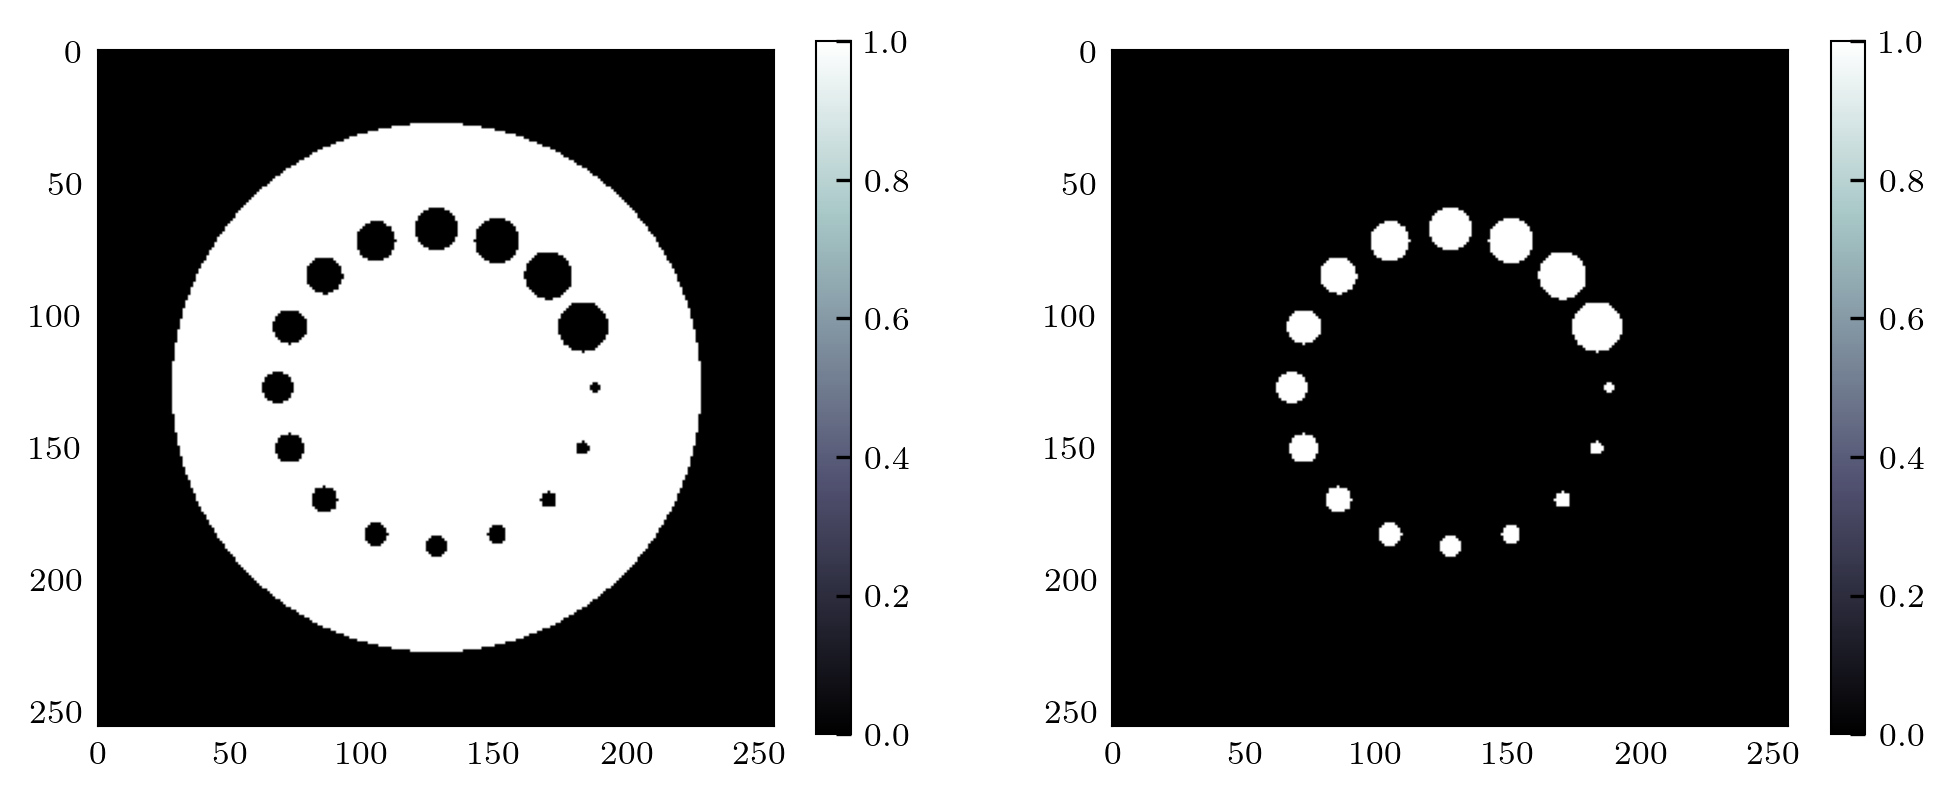

water [944.74866  72.80208]
aluminum [13038.745   1110.1404]
mu(E) ratios: [13.801285 15.248746]


In [59]:
# Make phantom

scale = 0.25

phantom = make_circle_cluster_phantom(
    Nx = int(1024 * scale),
    dx = 1.0,
    r_main = 400.0  * scale,
    r_ring = 240.0  * scale,
    r_smalls = jnp.arange(8, 40, 2) * scale
)

energies = jnp.array([8.0, 18.0])
bmat1, bmat2 = Water, Aluminum

mat1_arr = jnp.where(phantom==1, 1.0, 0.0)
mat2_arr = jnp.where(phantom==2, 1.0, 0.0)
fig, ax = plt.subplots(1, 2, figsize=[8,3])
for i in range(2):
    m = ax[i].imshow([mat1_arr, mat2_arr][i], cmap='bone')
    fig.colorbar(m, ax=ax[i])
plt.show()


dn1_vals, beta1_vals = jnp.array(bmat1.delta_beta(energies))
dn2_vals, beta2_vals = jnp.array(bmat2.delta_beta(energies))

wavenums = get_wavenum(energies)
mu1_vals = 2 * wavenums * beta1_vals
mu2_vals = 2 * wavenums * beta2_vals

print(bmat1.name, mu1_vals)
print(bmat2.name, mu2_vals)
print('mu(E) ratios:', mu2_vals/mu1_vals)

FOV = 0.512 mm
det dx = 2.00 um
slice dz = 32.00 um


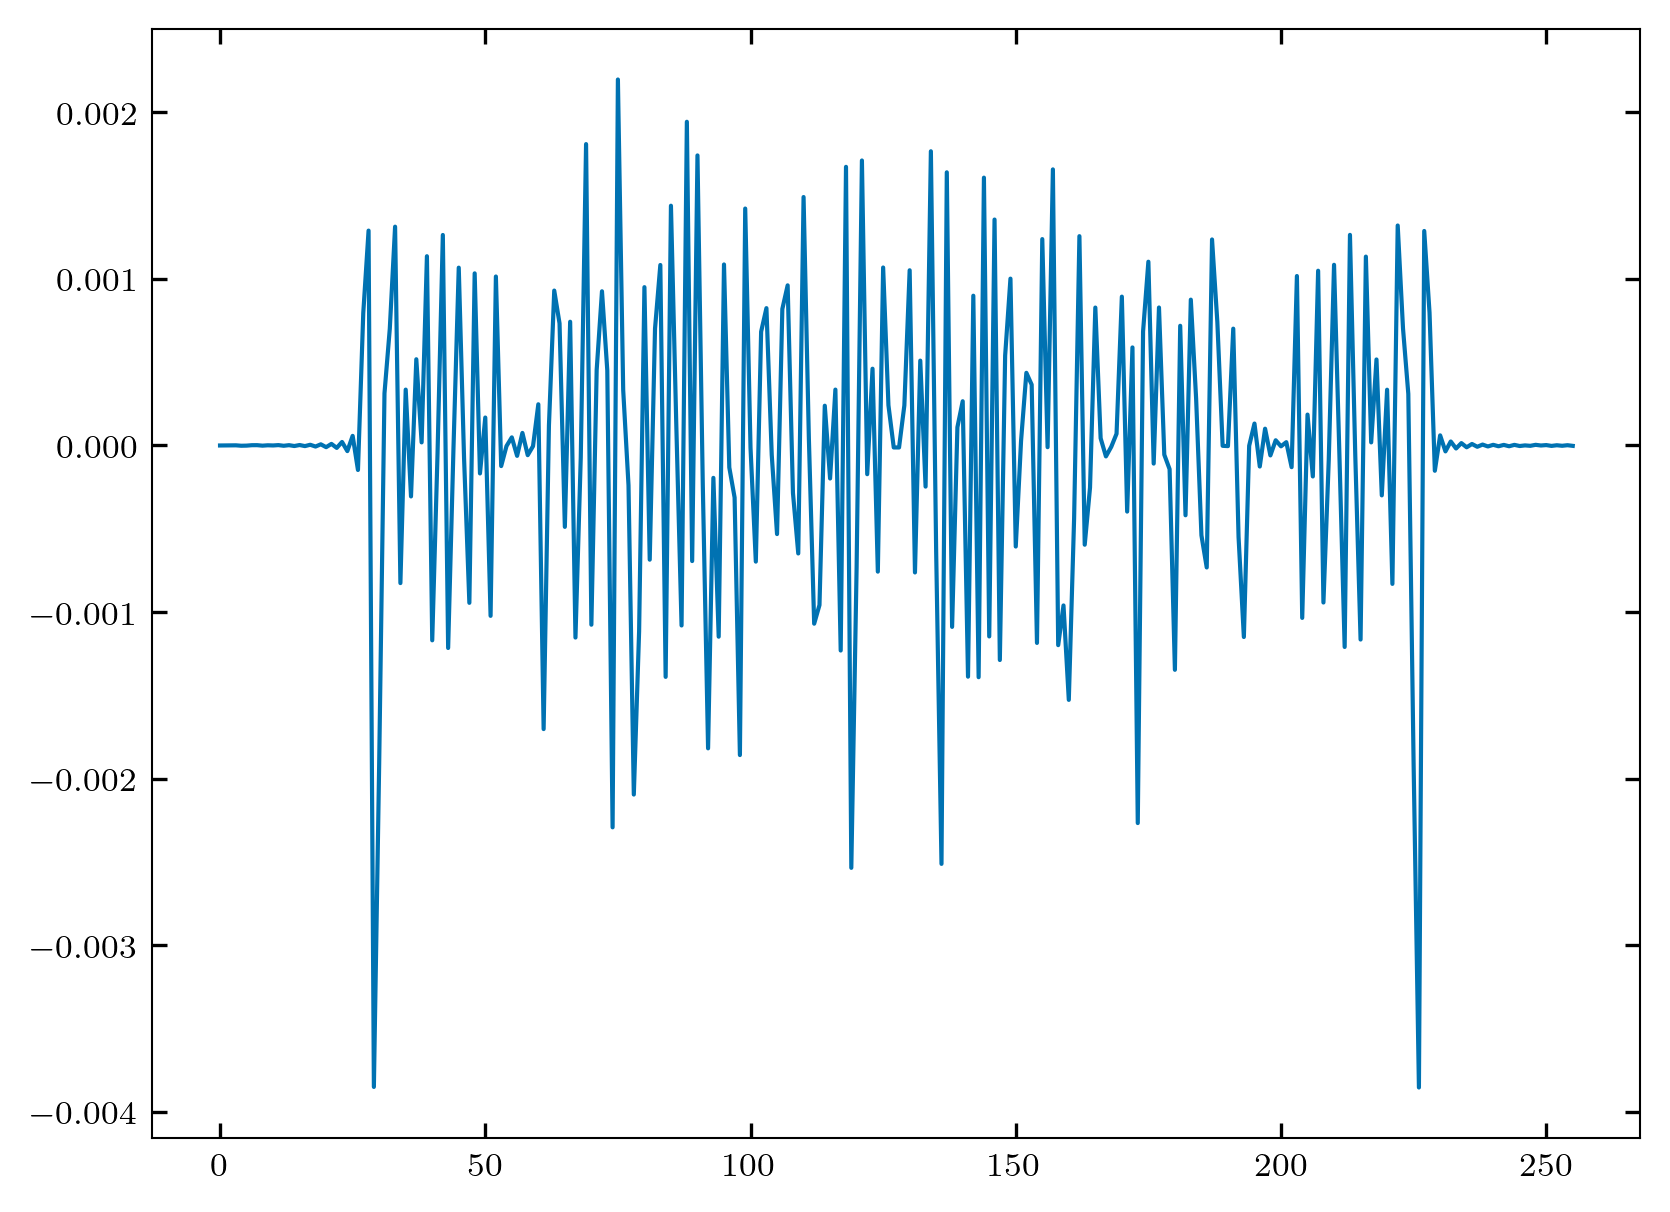

CPU times: user 1.95 s, sys: 287 ms, total: 2.24 s
Wall time: 708 ms


In [186]:
%%time

phantom_Nx = phantom.shape[0]
phantom_dx = 2e-6
fov = phantom_Nx*phantom_dx

det_upx = 1
det_Nx = phantom_Nx // det_upx
det_dx = fov / det_Nx

Nz = 16
dz = fov/Nz

thetas = jnp.linspace(0, jnp.pi, 361, endpoint=False)

print(f'FOV = {phantom_Nx * phantom_dx * 1e3:.3f} mm')
print(f'det dx = {fov/det_Nx * 1e6:.2f} um')
print(f'slice dz = {dz * 1e6:.2f} um')

shared_pars = dict(
    Nx = phantom_Nx,
    dx = phantom_dx,
    det_Nx = det_Nx,
    upx = det_upx,
    dz = dz,
    det_fwhm = None, #1e-6,
    det_psf = 'lorentzian',
    propdist = 0, # 10e-3,
    I0_per_um2 = 1/(phantom_dx * 1e6)**2,  #e3,  
    energies = energies,
    thetas = thetas,
    N_pad = 8,
    dn1_vals = dn1_vals,
    beta1_vals = beta1_vals,
    dn2_vals = dn2_vals,
    beta2_vals = beta2_vals,
)

pa_sim = ProjApproxPBI_1D(**shared_pars)
ms_sim = MultiSlicePBI_1D(**shared_pars)

imgs_pa = pa_sim.apply({}, mat1_arr, mat2_arr)
imgs_ms = ms_sim.apply({}, mat1_arr, mat2_arr)

# plt.plot(imgs_pa[0,0]); plt.plot(imgs_ms[0,0], 'r--')
plt.plot(imgs_pa[0,0]/imgs_pa.ravel()[0] - imgs_ms[0,0]/imgs_ms.ravel()[0])
plt.show()


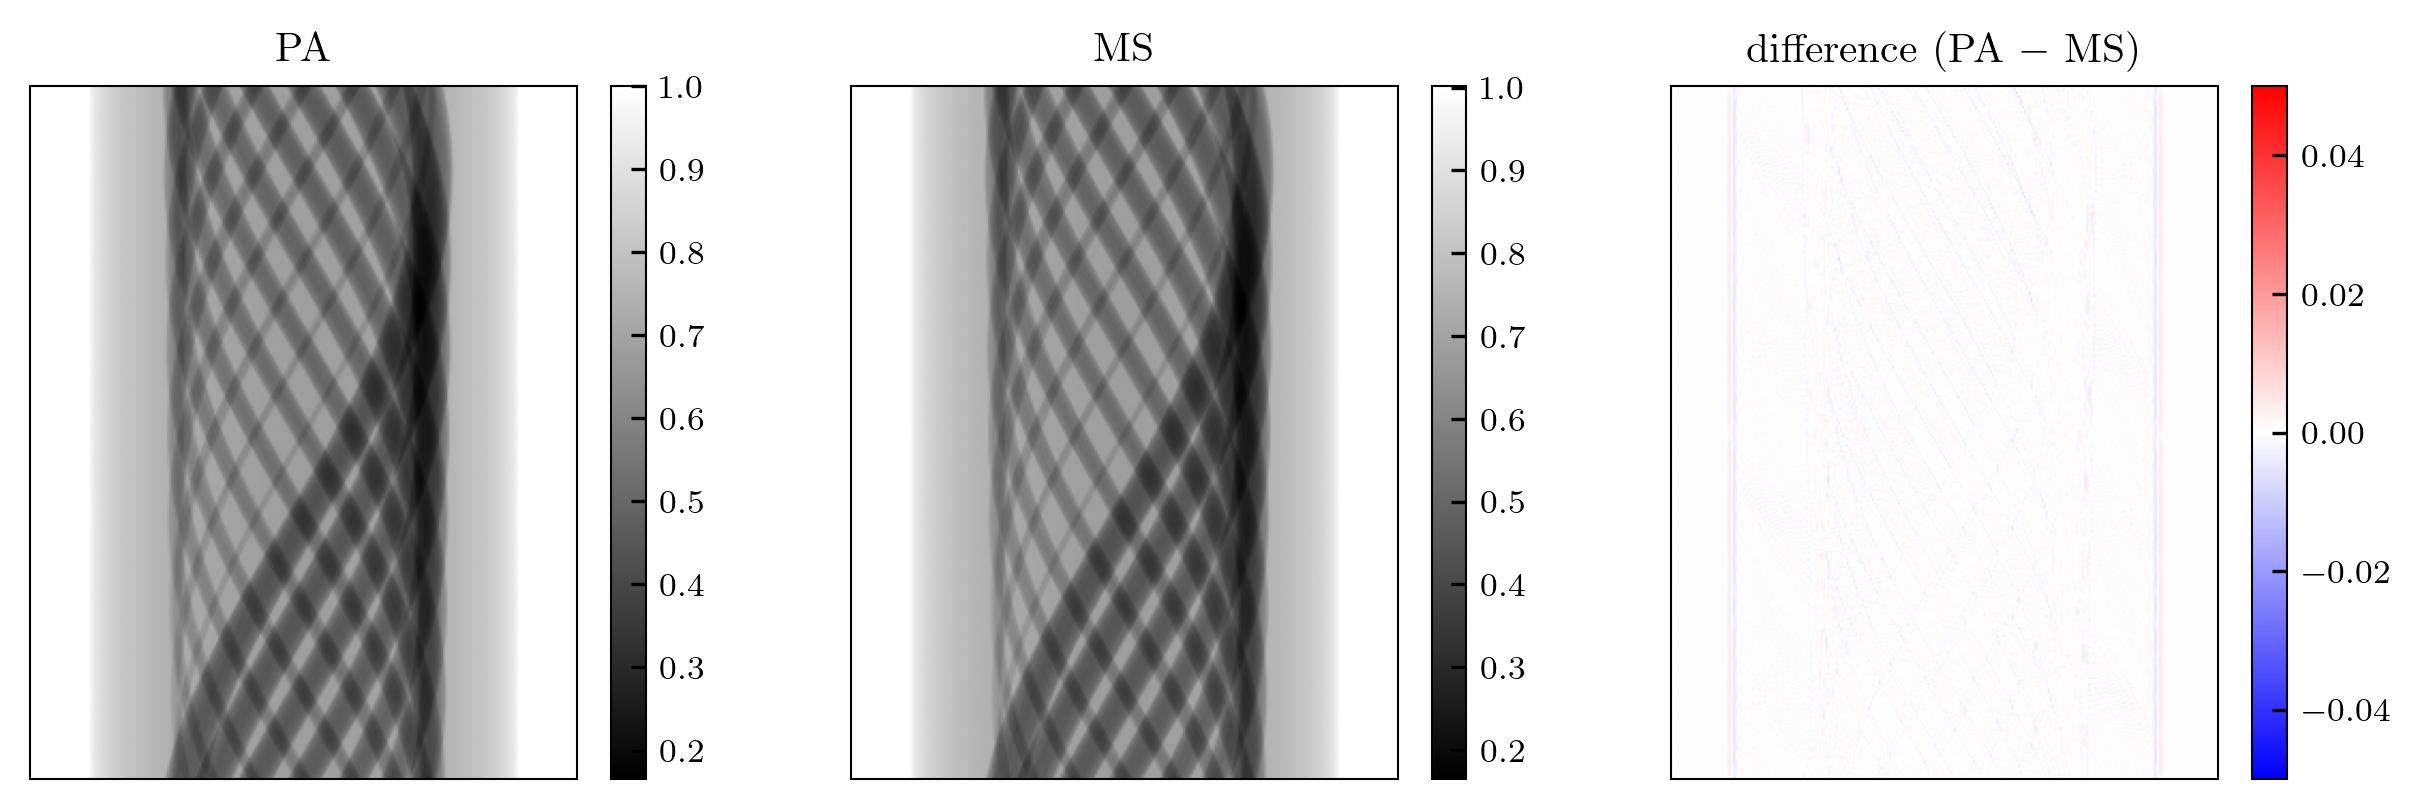

In [187]:

fig, ax = plt.subplots(1, 3, figsize=[10,3])
for i in range(2):
    ax[i].set_title(['PA', 'MS'][i])
    m = ax[i].imshow([imgs_pa, imgs_ms][i][0], aspect='auto')
    fig.colorbar(m, ax=ax[i])

ax[-1].set_title('difference (PA $-$ MS)')
diff = imgs_pa - imgs_ms
vm = 0.05 #jnp.abs(diff).max()
m = ax[-1].imshow(diff[0], aspect='auto', cmap='bwr', vmax=vm, vmin=-vm)
fig.colorbar(m, ax=ax[-1])

for axi in ax:
    axi.set_xticks([]); axi.set_yticks([])
plt.show()

# plt.plot(imgs_pa[0,0]); plt.plot(imgs_ms[0,0], 'r--')
# # plt.plot(imgs_pa[0,0]-imgs_ms[0,0])
# plt.show()

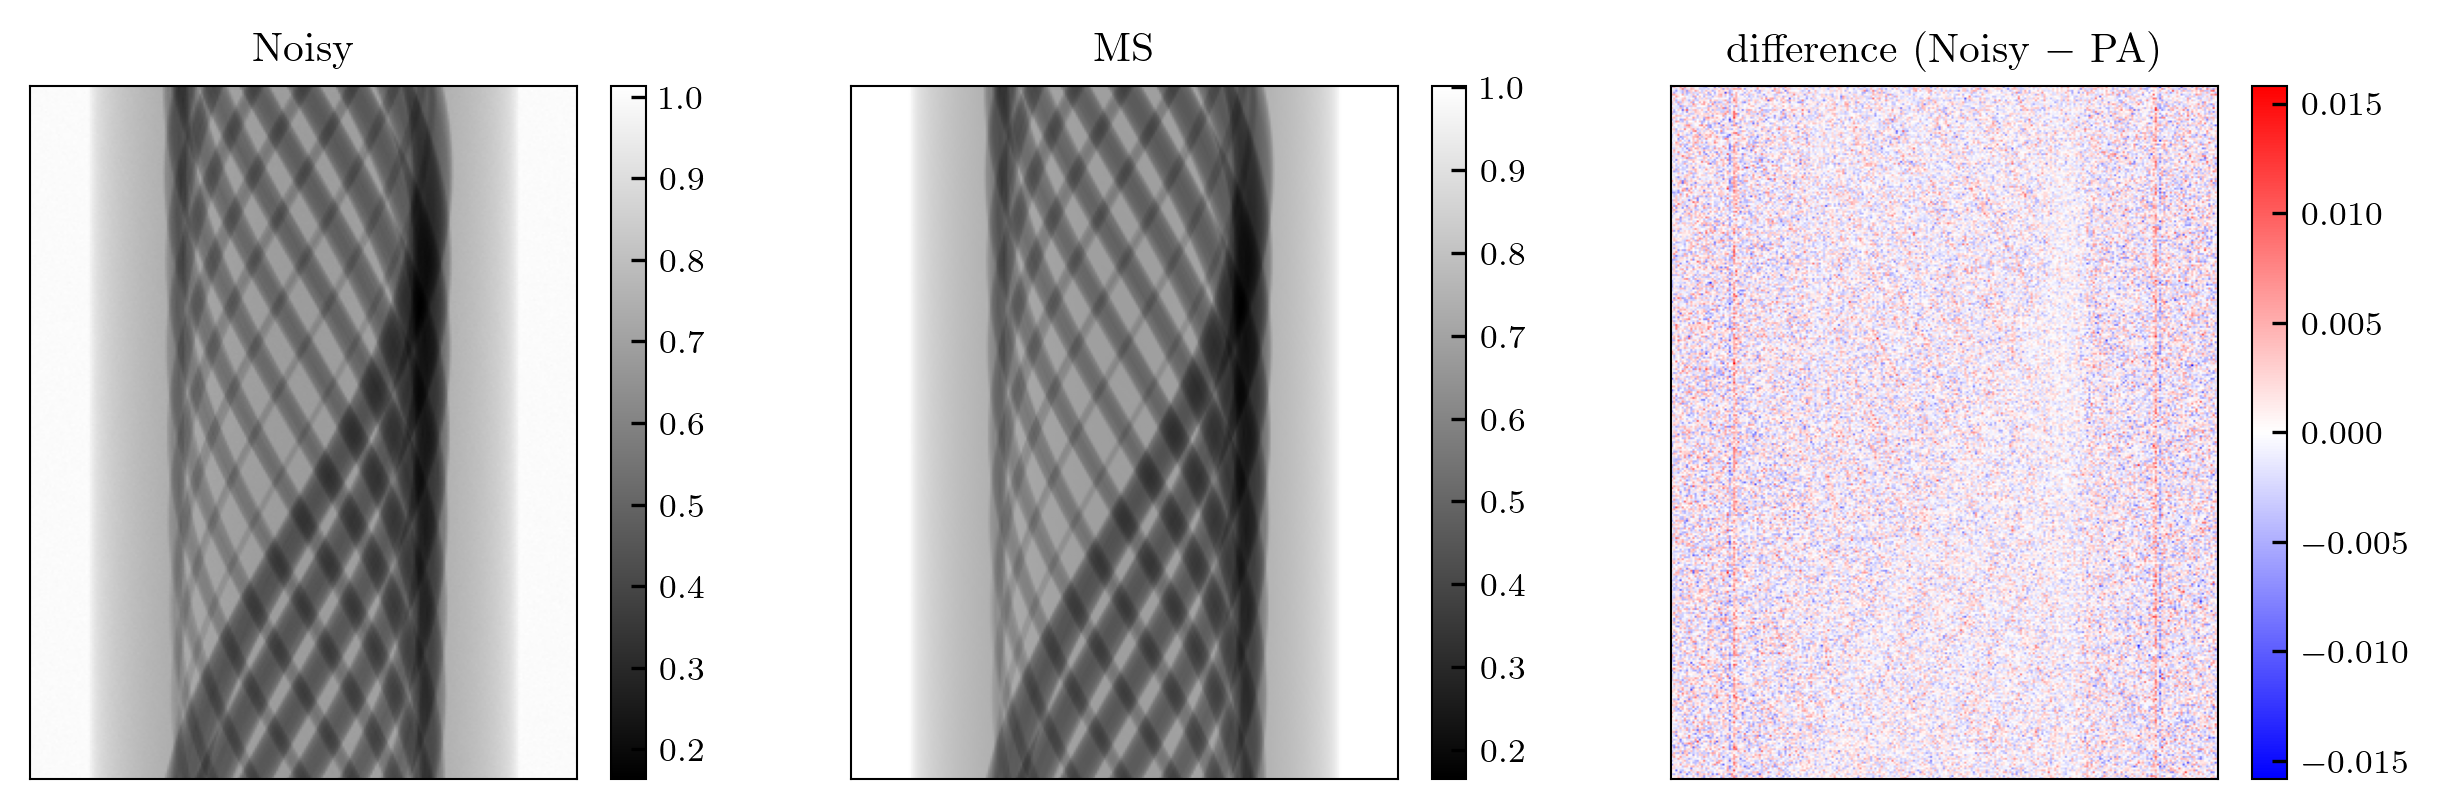

In [188]:
# Make noisy data

I0_per_px = 1e5
key = jax.random.PRNGKey(3)  

data_noisy = jax.random.poisson(key, I0_per_px*imgs_ms, imgs_ms.shape) / I0_per_px

fig, ax = plt.subplots(1, 3, figsize=[10,3])
for i in range(2):
    ax[i].set_title(['Noisy', 'MS'][i])
    m = ax[i].imshow([data_noisy, imgs_ms][i][0], aspect='auto')#, vmax=0.99, vmin=0.5)
    fig.colorbar(m, ax=ax[i])

ax[-1].set_title('difference (Noisy $-$ PA)')
diff = data_noisy - imgs_pa
vm = min(0.1, jnp.abs(diff).max())
m = ax[-1].imshow(diff[0], aspect='auto', cmap='bwr', vmax=vm, vmin=-vm)
fig.colorbar(m, ax=ax[-1])

for axi in ax:
    axi.set_xticks([]); axi.set_yticks([])
plt.show()

# Simple materials estimate

In [ ]:
%%time
 
N_matrix = shared_pars['det_Nx']
s = det_dx
FOV = N_matrix*s
dtheta = np.diff(shared_pars['thetas'])[0]
propdist = shared_pars['propdist']

maxval = 100  # clip material density

recons_energy = []

    
for i, energy in enumerate(energies):
    print(energy)

    imgs = data_noisy
    
    sino_log = -jnp.log(imgs[i].clip(0, 1))
    
    r_matrix, theta_matrix = get_recon_coords(N_matrix, FOV)
    H = make_ramp_filter_fourier(sino_log.shape[1], s, cutoff_frac=0.1, window='hann') 
    
    sino_filtered = pre_process_fft(sino_log, s, H)
    
    recon = do_fbp_vmap(sino_filtered, r_matrix, theta_matrix, s, dtheta)
    recons_energy.append(recon.T[::-1,::-1])

fig, ax = plt.subplots(1,2, figsize=[8,3], layout='constrained')
for i in range(2):
    m = ax[i].imshow(recons_energy[i])
    fig.colorbar(m, ax=ax[i])
plt.show()


# 2x2 mat decomp
MU = jnp.array([
    [mu1_vals[0], mu2_vals[0]],
    [mu1_vals[1], mu2_vals[1]],
])

recons_energy = jnp.stack(recons_energy)  # (2, Ny, Nx)

b = recons_energy.reshape(2, -1)
mats = jnp.linalg.solve(MU, b)

mat1_recon = mats[0].reshape(recons_energy.shape[1:])
mat2_recon = mats[1].reshape(recons_energy.shape[1:])

mat1_recon = jnp.clip(mat1_recon, 0.0, maxval)
mat2_recon = jnp.clip(mat2_recon, 0.0, maxval)

recons_mats = jnp.stack([mat1_recon, mat2_recon])
fig, ax = plt.subplots(1, 2, figsize=[8,3], layout='constrained')
for i in range(2):
    m = ax[i].imshow(recons_mats[i])
    ax[i].set_title(['mat1', 'mat2'][i])
    fig.colorbar(m, ax=ax[i])
plt.show()

# Optimization

In [204]:
# Regularization

def tv_aniso(x):
    tv_x = jnp.mean(jnp.abs(x[:, 1:] - x[:, :-1]))
    tv_y = jnp.mean(jnp.abs(x[1:, :] - x[:-1, :]))

    return tv_x + tv_y


def vtv(params, c1=1e-6, c2=1e-9, eps=1e-8):
    im1, im2 = params_to_imgs(params)

    im1 = im1 / c1
    im2 = im2 / c2

    im1_x = im1[:, 1:] - im1[:, :-1]
    im1_y = im1[1:, :] - im1[:-1, :]

    im2_x = im2[:, 1:] - im2[:, :-1]
    im2_y = im2[1:, :] - im2[:-1, :]

    vtv_x = jnp.sqrt(im1_x**2 + im2_x**2 + eps)
    vtv_y = jnp.sqrt(im1_y**2 + im2_y**2 + eps)

    return jnp.mean(vtv_x) + jnp.mean(vtv_y)


def diff_x(x):
    return x[..., 1:] - x[..., :-1]


def overlap_penalty(params, mask=None, eps=1e-8):
    im1, im2 = params_to_imgs(params)

    s1 = jnp.maximum(jnp.max(jax.lax.stop_gradient(jnp.abs(im1))), eps)
    s2 = jnp.maximum(jnp.max(jax.lax.stop_gradient(jnp.abs(im2))), eps)

    m1n = im1 / s1
    m2n = im2 / s2

    r = (m1n * m2n)**2

    # if mask is not None:
    #     mask = jax.lax.stop_gradient(mask.astype(r.dtype))
    #     return jnp.sum(mask * r) / (jnp.sum(mask) + eps)

    return jnp.mean(r)

In [203]:
# Set up

def init_recon_params(Nx):#, key=jax.random.PRNGKey(3), c=1e-5):
    # m1, m2 = (c + (c/2)*jax.random.normal(key, (2,Nx,Nx))).clip(0, None)
    params = dict(
        mat1 = mat1_recon,  # must define this above!!
        mat2 = mat2_recon,  
        # mat1 = jnp.zeros((Nx, Nx)),
        # mat2 = jnp.zeros((Nx, Nx)),
        # mat1 = 0*m1,
        # mat2 = 0*m2
    )
    return params


def clip_params(params):
    params = dict(
        mat1 = jnp.maximum(params['mat1'], 0.0),
        mat2 = jnp.maximum(params['mat2'], 0.0),
    )
    return params


def params_to_imgs(params):
    return params['mat1'], params['mat2']


def plot_pars(params):
        
    mat1_rec, mat2_rec = params_to_imgs(params)
    
    fig, ax = plt.subplots(1, 3, figsize=[12, 3])
    
    m0 = ax[0].imshow(mat1_rec)
    ax[0].set_title('img 1')
    fig.colorbar(m0, ax=ax[0])
    
    m1 = ax[1].imshow(mat2_rec)
    ax[1].set_title('img 2')
    fig.colorbar(m1, ax=ax[1])
    
    ax[2].plot(jnp.asarray(loss_hist), '.-')
    ax[2].set_title('loss')
    ax[2].set_yscale('log')
    
    plt.tight_layout()
    plt.show()

0 loss = 0.015019151382148266 L2 = 0.015015176497399807 reg = 3.9746914808347356e-06


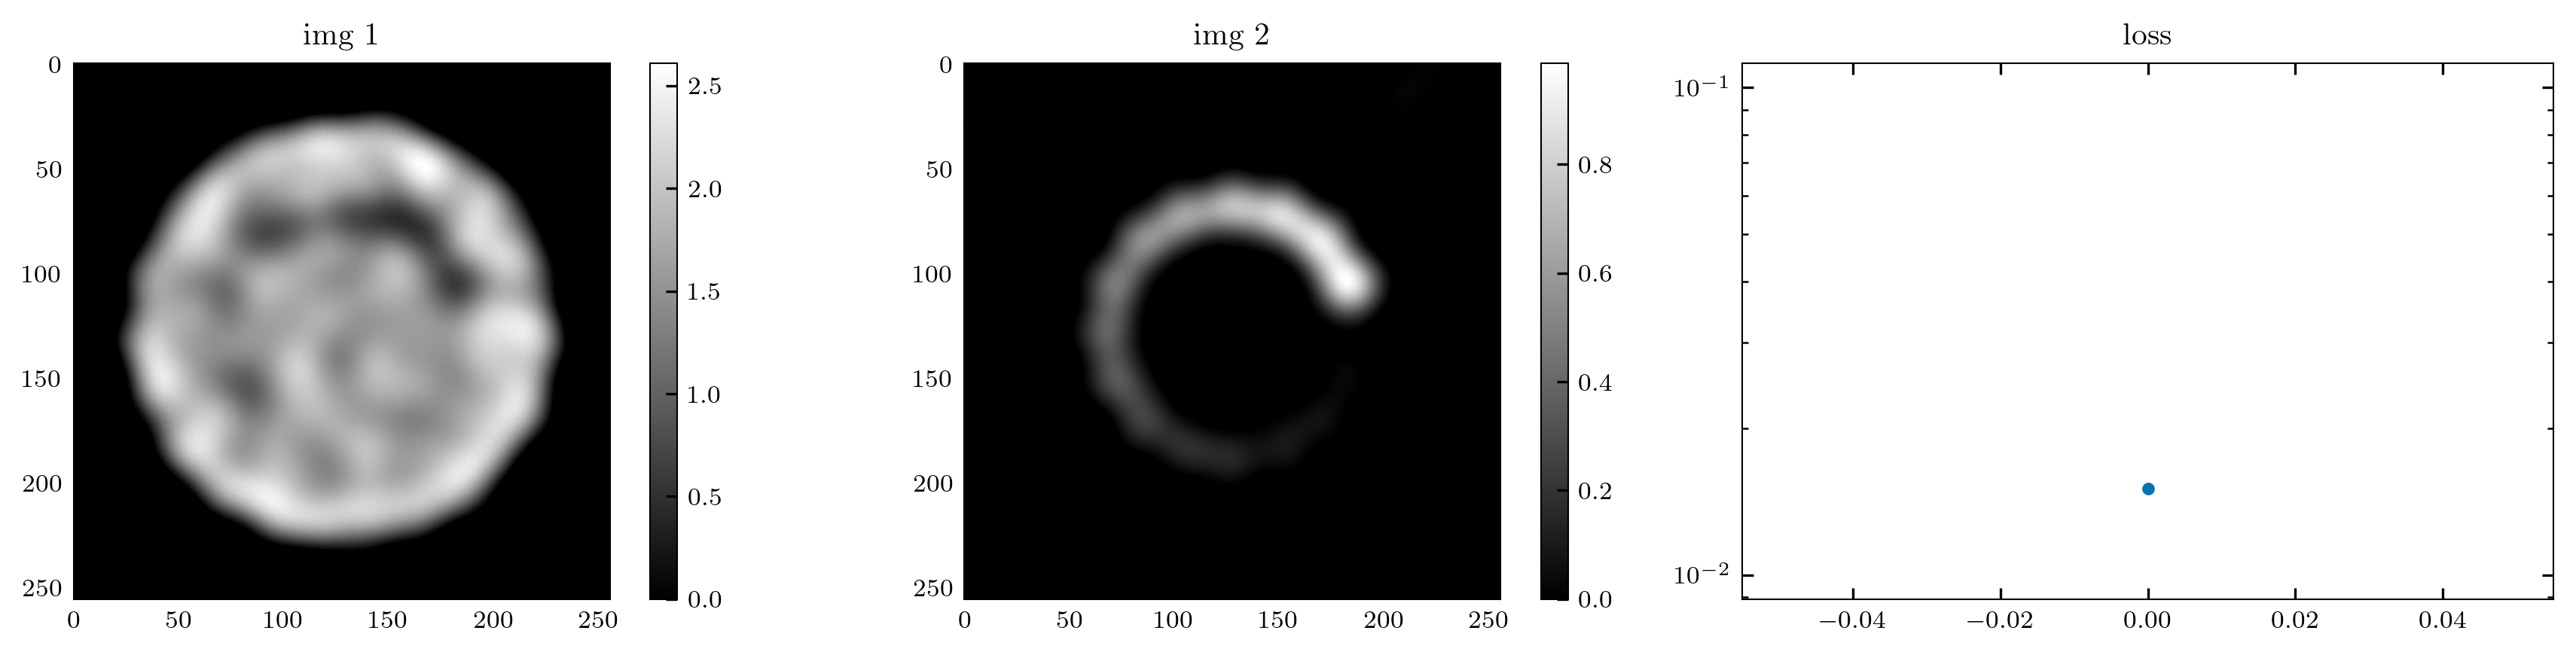

10 loss = 0.007946874015033245 L2 = 0.007944290526211262 reg = 2.5838294277491514e-06


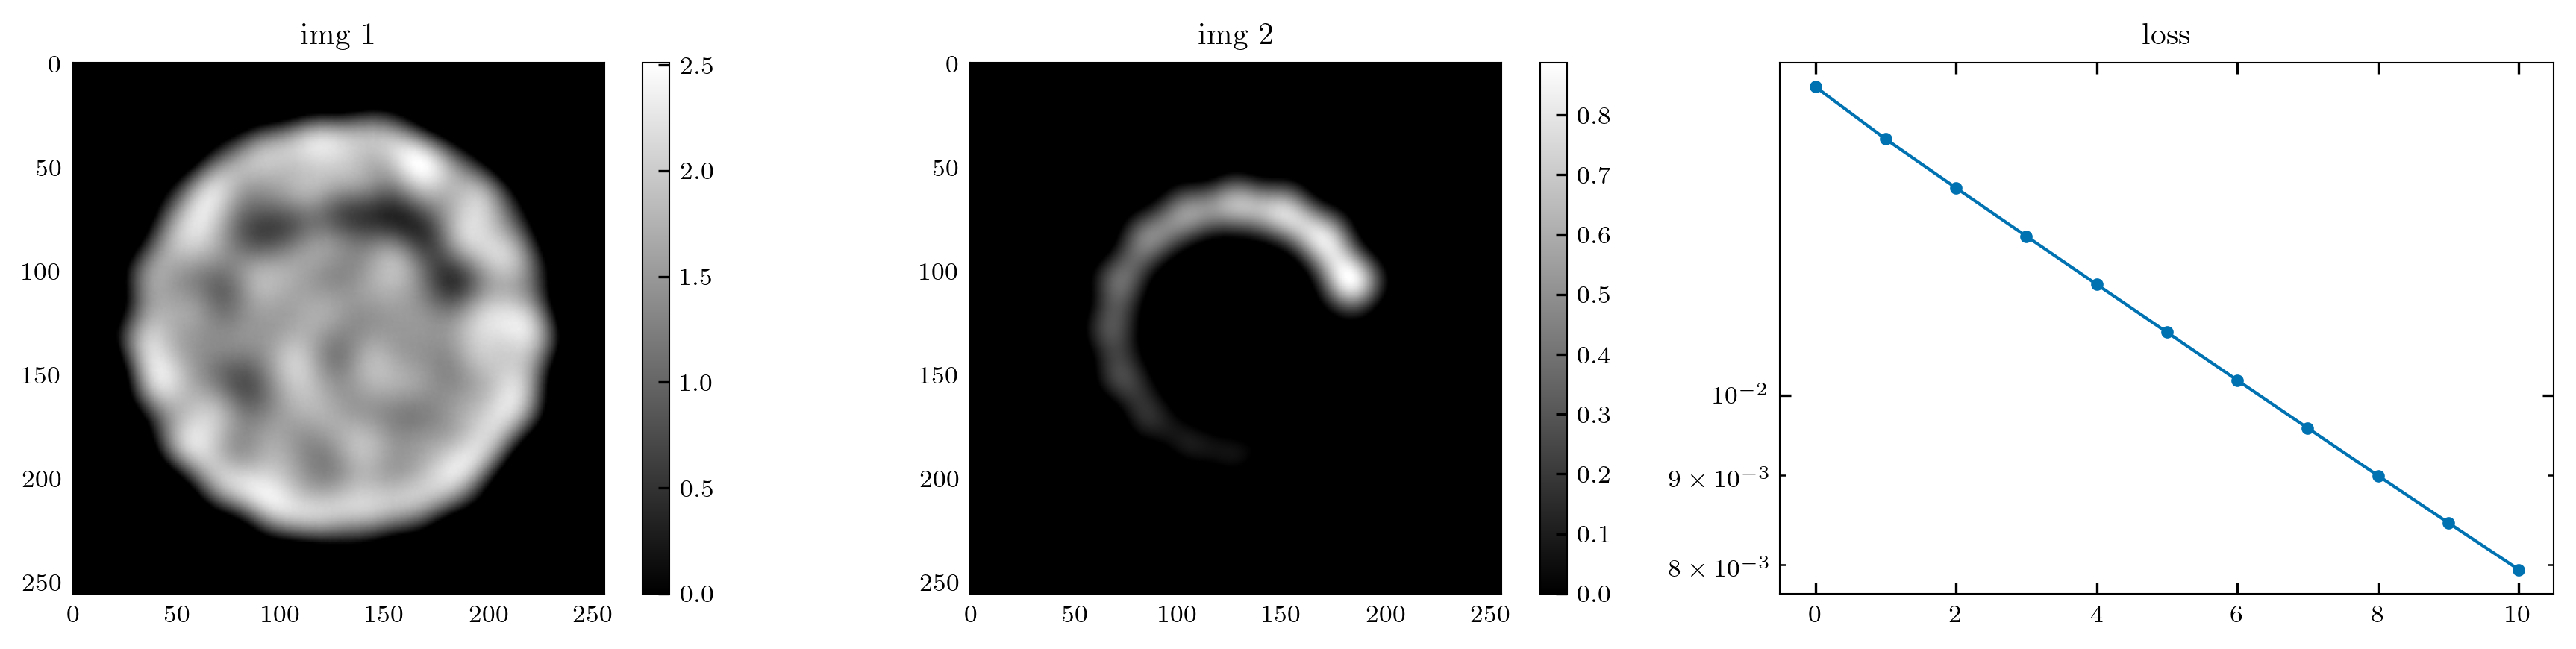

20 loss = 0.004530624020844698 L2 = 0.004528942983597517 reg = 1.6807805423013633e-06


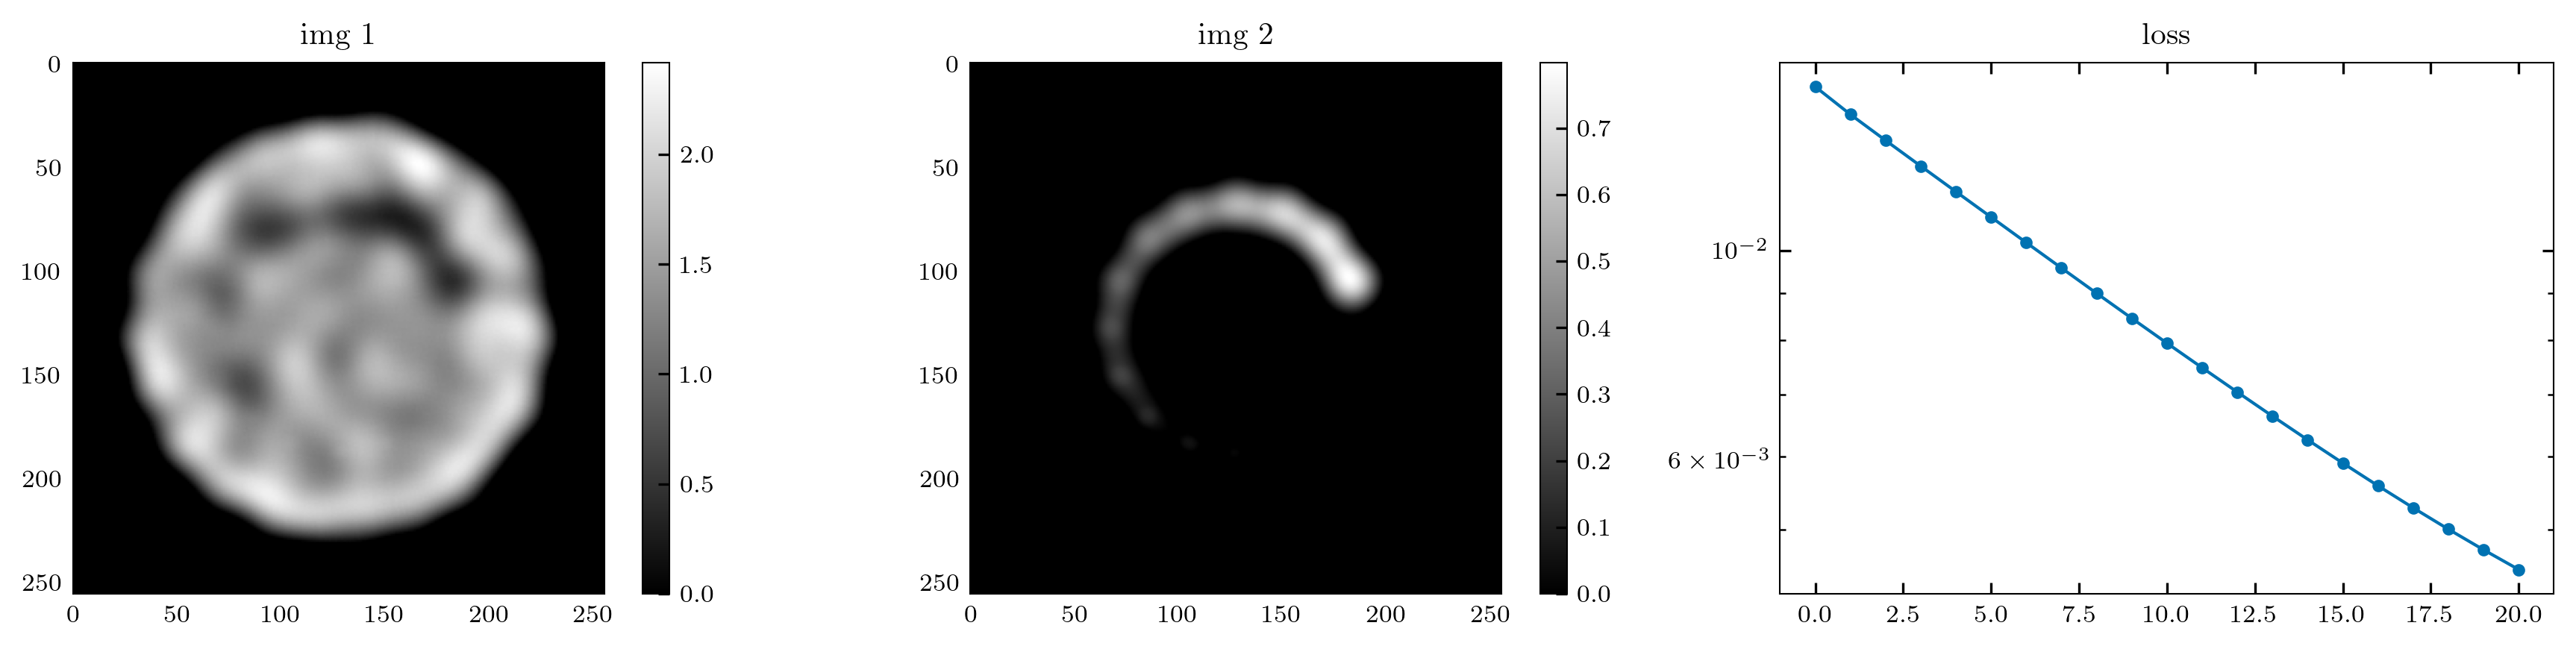

30 loss = 0.0031066867522895336 L2 = 0.003105460898950696 reg = 1.2258230981387896e-06


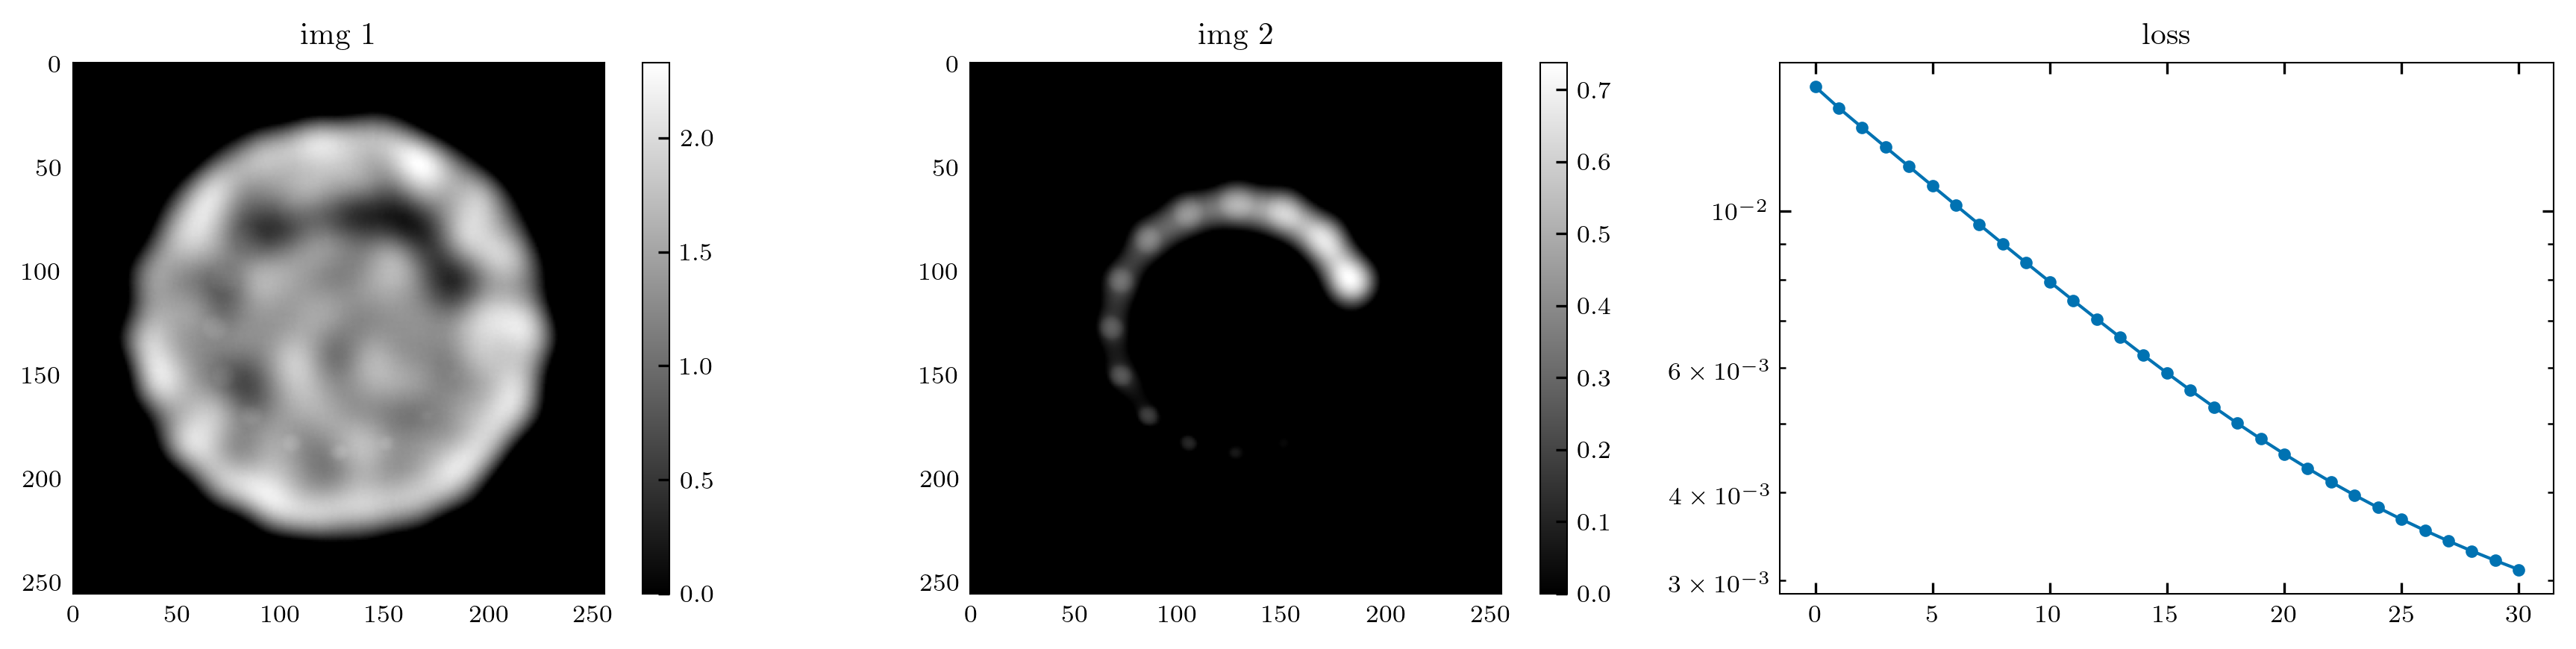

40 loss = 0.0023977989330887794 L2 = 0.002396540716290474 reg = 1.2581264172695228e-06


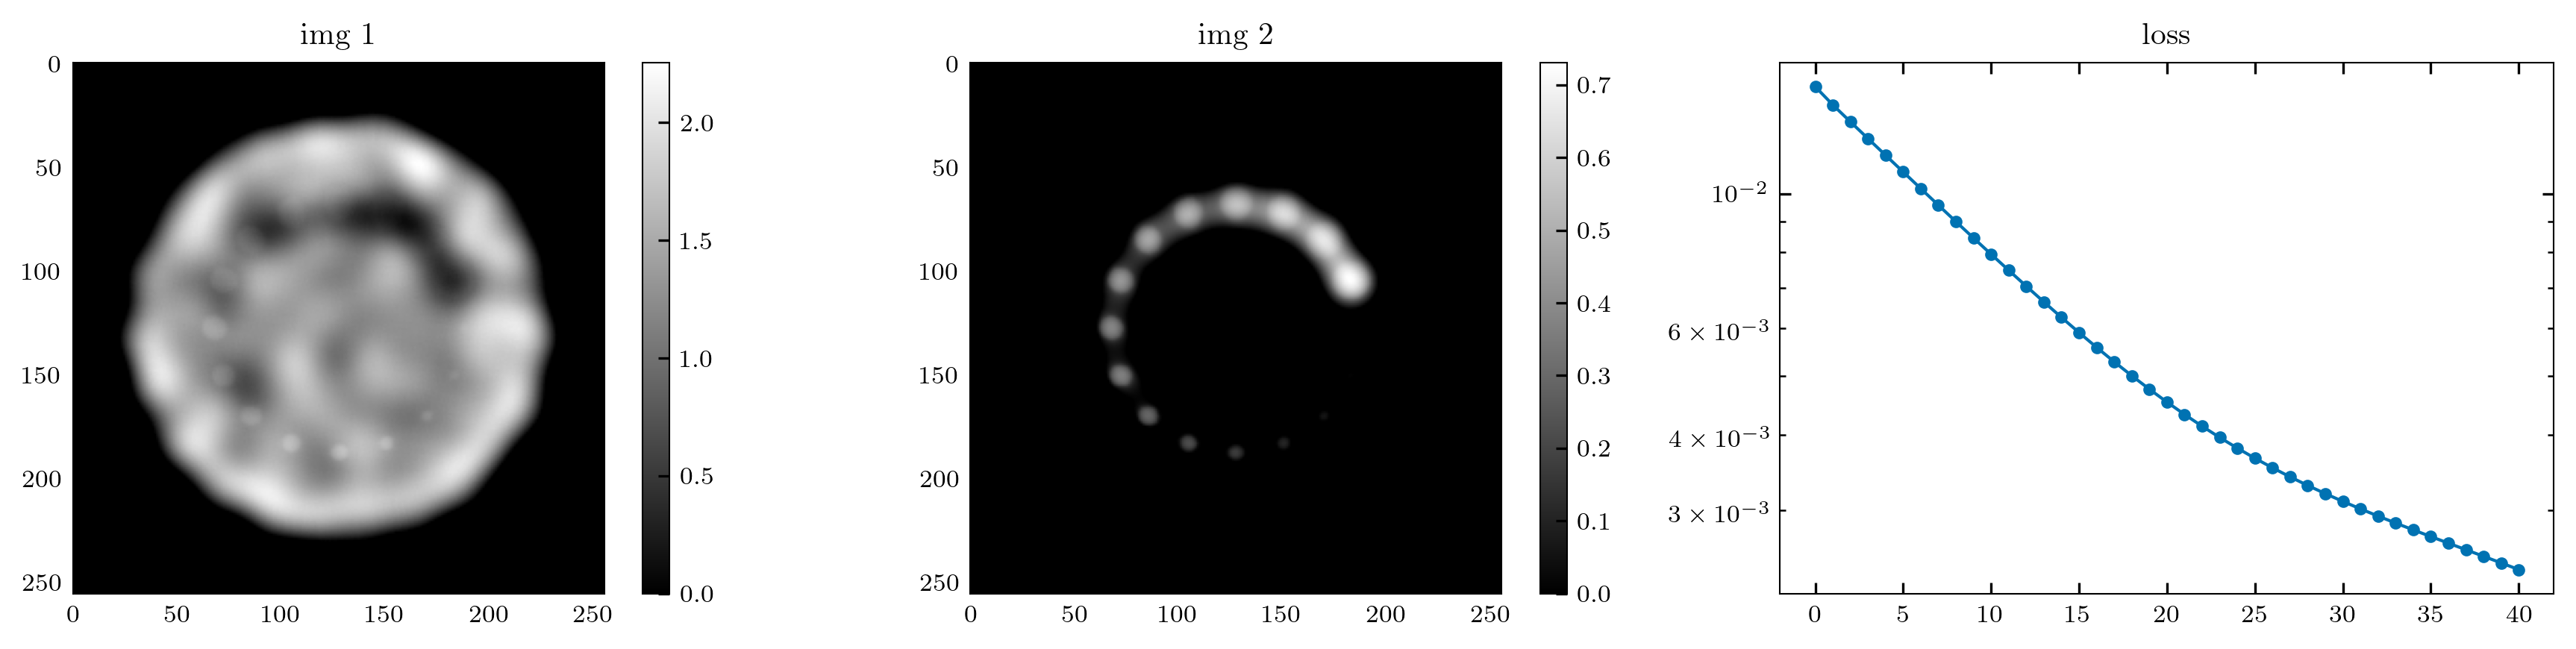

50 loss = 0.001831527566537261 L2 = 0.0018298049690201879 reg = 1.7226723230123753e-06


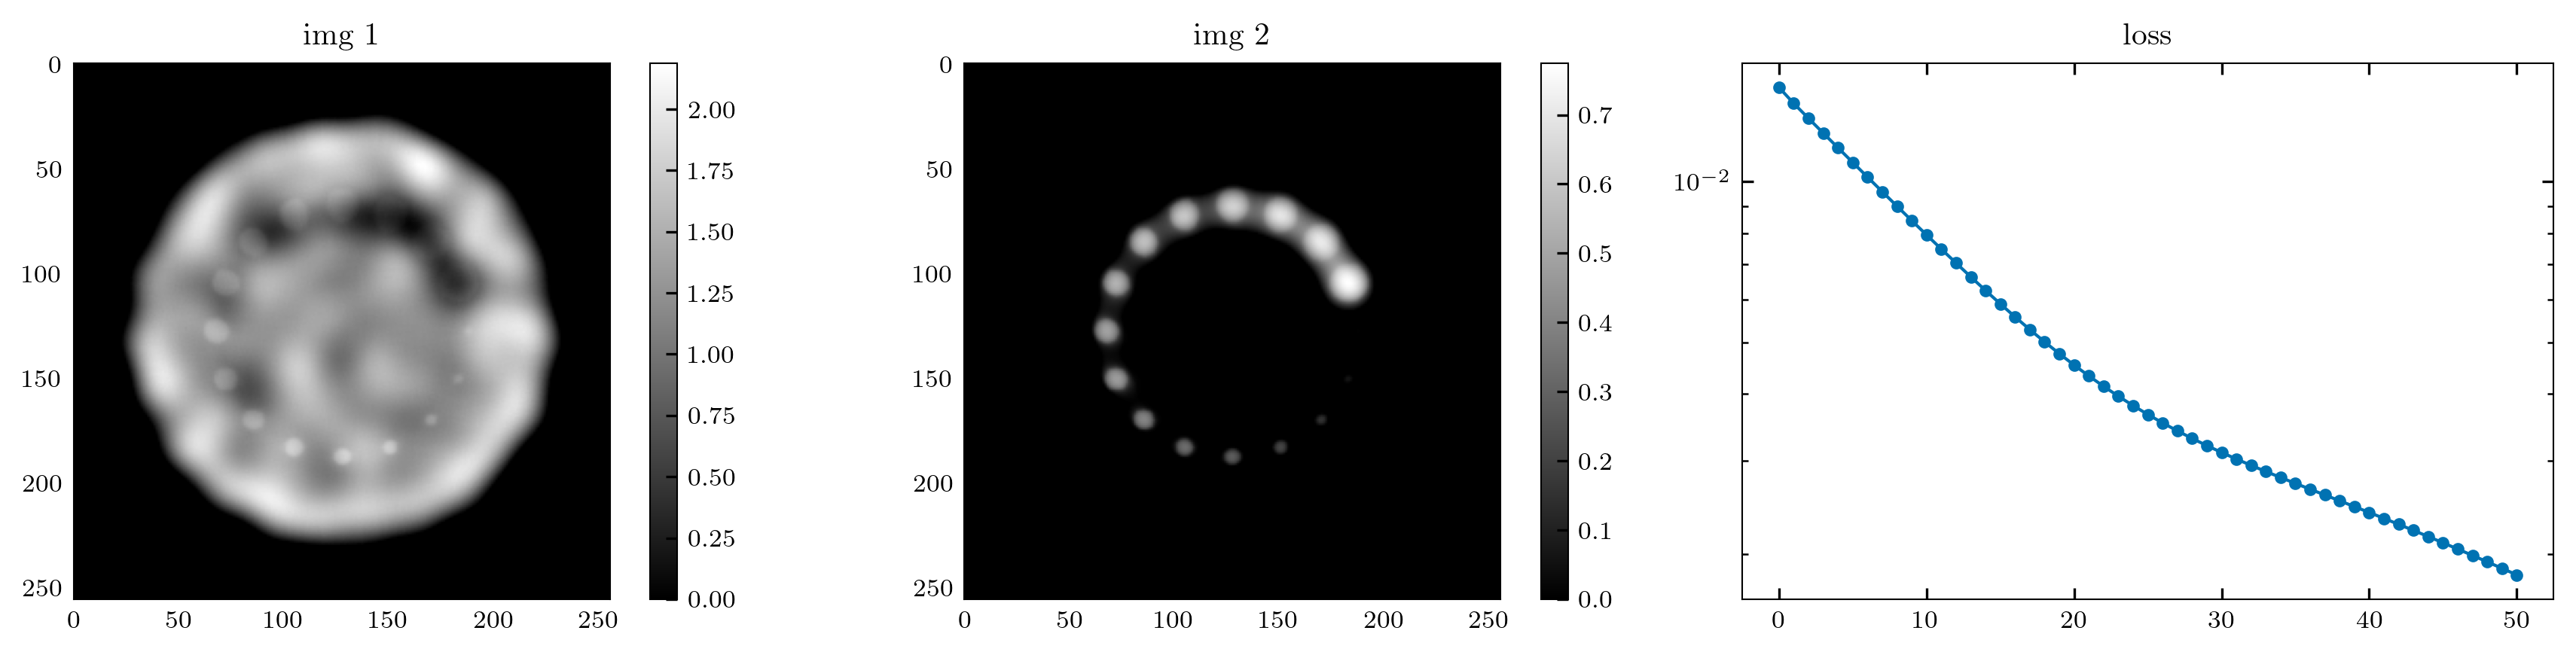

CPU times: user 2min 36s, sys: 1min 25s, total: 4min 2s
Wall time: 45.9 s


In [207]:
%%time

# recon_model = MultiSlicePBI_1D      # use MS model for inversion
recon_model = ProjApproxPBI_1D    # use PA model for inversion

recon_opt = recon_model(**shared_pars)

data = imgs_pa  #data_noisy


######################################################

def project_phantom(params):
    return recon_opt.apply({}, params['mat1'], params['mat2'])

def loss_fn(params, data, lam_overlap=0.0, lam_vtv=0.0, lam_edge=0.0):
    y = project_phantom(params)

    fidelity = jnp.mean((y - data)**2)
    # fidelity = jnp.mean((jnp.log(y) - jnp.log(data))**2)

    r_overlap = lam_overlap * overlap_penalty(params)
    # r_vtv = lam_vtv * vtv(params)
    # r_edge = lam_edge * jnp.mean((diff_x(pred) - diff_x(data))**2)

    loss = fidelity + r_overlap 

    aux = dict(
        loss = loss,
        fidelity = fidelity,
        priors = r_overlap,
    )

    return loss, aux

@jax.jit
def train_step(params, opt_state, data):
    (loss, aux), grads = jax.value_and_grad(
        loss_fn,
        has_aux=True,
    )(
        params,
        data,
        lam_overlap=1e-3,
        lam_vtv=0,
        lam_edge=0
    )

    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    params = clip_params(params)

    return params, opt_state, aux


######################################################
params = init_recon_params(shared_pars['Nx'])

optimizer = optax.adam(
    learning_rate = 1e-2,
    # momentum = 0.5
)

opt_state = optimizer.init(params)

loss_hist = []

for it in range(51):
    params, opt_state, aux = train_step(
        params,
        opt_state,
        data,
    )

    loss_hist.append(aux['loss'])

    if it % 10 == 0:
        print(
            it,
            'loss =', float(aux['loss']),
            'L2 =', float(aux['fidelity']),
            'reg =', float(aux['priors']),
        )

        plot_pars(params)

# Init estimates?